In [75]:
import numpy as np
import math
import copy
import random
import itertools
from itertools import chain
from collections import Counter
import matplotlib.pyplot as plt

In [76]:
###### Create list of candidate maximizers: periodic orbits up to period 14
#Import list of lyndon words up to length 14
lyndonWords=open("Lyndon Words.txt", 'r').read().splitlines();

#Make list of periods (lengths) of each word
periods=list(map(len,lyndonWords))

#Make list of decimals in [0,1] with periodic orbit represented by each lyndon word
def lwToFraction(word):
    fraction=0;
    for i in range(len(word)):
        fraction+=(int(word[i])*(1/2**(i+1)))/(1 - (1/2**len(word)));
    return fraction

decimalPoints=list(map(lwToFraction,lyndonWords))

In [77]:
###### Function to caluclate interlacing number of a given lyndon word
def interlacing(word):
    orbit=[lwToFraction(word)];
    for i in range(len(word)-1):
        orbit.append(2*orbit[-1]%1)
    #print(orbit)
    antiorbit=[];
    for i in range(len(orbit)):
        antiorbit.append((orbit[i]+.5)%1)
    #print(antiorbit)
    list=orbit+antiorbit
    list.sort()
    #print(list)
    iln=0;
    for i in range(len(list)):
        if list[i] in orbit and list[(i+1)%len(list)] in antiorbit:
            iln+=1;
    return iln

In [78]:
#Interalcing numbers of candidate orbits
allilns=list(map(interlacing,lyndonWords))
maxiln=max(allilns)
allcounts = Counter(allilns)
allresult = {i: allcounts[i] for i in range(1, maxiln+1, 2)}
print(allresult)

{1: 65, 3: 470, 5: 1006, 7: 742, 9: 227, 11: 28}


In [79]:
###### Functions for integrating
#The potential
def f(a,b,c,d,x):
    return a*math.cos(2*math.pi*x)+b*math.sin(2*math.pi*x)+c*math.cos(6*math.pi*x)+d*math.sin(6*math.pi*x)

#Function integrates trig polynomial with given coefficients against given orbit with given period
def integrate(a,b,c,d,dec,p):
    integral=0;
    for i in range(p):
        integral+=(1/p)*f(a,b,c,d,dec*2**(i))
    return integral

#Function integrates trig polynomial given by coefficients in tuple against all orbits, returns the LW that maximizes
def pseudomaxmeas(tuple):
    integrals = list(map(integrate,itertools.repeat(tuple[0]),itertools.repeat(tuple[1]),itertools.repeat(tuple[2]),itertools.repeat(tuple[3]),decimalPoints,periods))
    indexofmax= integrals.index(max(integrals))
    return lyndonWords[indexofmax]

In [82]:
###### Experiment: 
#Generate random coefficients for the trig polynomials, map pseudomaxmeas over generated tuples
raw=[np.random.normal(0,1),np.random.normal(0,1),np.random.normal(0,1),np.random.normal(0,1),np.random.normal(0,1),np.random.normal(0,1)]
randomcoeffs=[[float(i)/np.linalg.norm(raw) for i in raw]]
for i in range(40000):
    raw=[np.random.normal(0,1),np.random.normal(0,1),np.random.normal(0,1),np.random.normal(0,1),np.random.normal(0,1),np.random.normal(0,1)]
    norm = [float(i)/np.linalg.norm(raw) for i in raw]
    randomcoeffs.append(norm)
maxmeas=list(map(pseudomaxmeas,randomcoeffs))

#Map interlacing over maxmeas
ilns=list(map(interlacing,maxmeas))
#Tally how many of each interlacing show up as maximizing measures
counts = Counter(ilns)
result = {i: counts[i] for i in range(1, maxiln+1, 2)}
print(result)

{1: 31447, 3: 8554, 5: 0, 7: 0, 9: 0, 11: 0}


In [72]:
#Print or write to file
#print(list(zip(randomcoeffs,maxmeas,ilns)))
#with open("output.txt", "w") as f:
#    for ai, bi, ci in zip(randomcoeffs, maxmeas, ilns):
#        f.write(f"{ai},{bi},{ci}\n")

-------------------------------

# Visulaizing interlacing number

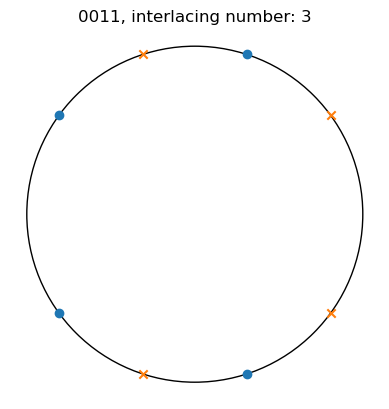

In [73]:
wordtoplot='0011'; #change this as desired
#create orbit and antiorbit
orbittoplot=[lwToFraction(wordtoplot)]
for i in range(len(wordtoplot)-1):
    orbittoplot.append(2*orbittoplot[-1]%1)
antiorbittoplot=[];
for i in range(len(orbittoplot)):
    antiorbittoplot.append((orbittoplot[i]+.5)%1)
    
#turn orbit and antiorbit into x,y coordinates on unit circle
def numtocoord(x):
    return [math.cos(2*math.pi*x),math.sin(2*math.pi*x)]
orbitcoords=list(map(numtocoord,orbittoplot))
antiorbitcoords=list(map(numtocoord,antiorbittoplot))
orbit_x, orbit_y = zip(*orbitcoords)
anti_x, anti_y = zip(*antiorbitcoords)

#plot everything on one figure
figure, axes = plt.subplots()
unit_circle = plt.Circle( (0, 0 ),
                                      1 ,
                                      fill = False )

axes.set_aspect( 1 )
axes.add_artist( unit_circle )
axes.axis('off')
plt.scatter(orbit_x,orbit_y,marker='o')
plt.scatter(anti_x,anti_y,marker='x')
plt.xlim(-1.1, 1.1) # Set x-axis
plt.ylim(-1.1, 1.1) # Set y-axis
plt.title(wordtoplot+", interlacing number: "+str(interlacing(wordtoplot)))
plt.savefig('0011iln.png')
plt.show()
